<a href="https://colab.research.google.com/github/dhammdiplokhande1595/Project_1/blob/main/Salary_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [32]:
df = pd.read_csv("Salary_Data.csv")

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [34]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [35]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [36]:
df.isnull().sum().sum()

np.int64(17)

In [37]:
num = df.select_dtypes(include=["int64","float64"])

In [38]:
cat = df.select_dtypes(include=["object"])

In [39]:
cat.columns

Index(['Gender', 'Education Level', 'Job Title'], dtype='object')

In [40]:
# numerical columns → mean
num_cols = ['Age','Years of Experience','Salary']
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# categorical columns → mode
cat_cols = ['Gender','Education Level','Job Title']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# verify
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [41]:
display(df.head())

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [42]:
# Define categorical columns to be label encoded
cat_cols_to_encode = ['Gender', 'Education Level', 'Job Title']
X = df.drop('Salary', axis=1)
y = df['Salary']
print("Independent Variables (X):")
display(X.head())

print("\nDependent Variable (y):")
display(y.head())

Independent Variables (X):


,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,Male,Bachelor's,Software Engineer,5.0
1,28.0,Female,Master's,Data Analyst,3.0
2,45.0,Male,PhD,Senior Manager,15.0
3,36.0,Female,Bachelor's,Sales Associate,7.0
4,52.0,Male,Master's,Director,20.0



Dependent Variable (y):


,Salary
0,90000.0
1,65000.0
2,150000.0
3,60000.0
4,200000.0


In [43]:
cat_cols_to_encode = ['Gender', 'Education Level', 'Job Title']
for col in cat_cols_to_encode:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

print("Independent Variables (X) after Label Encoding:")
display(X.head())

Independent Variables (X) after Label Encoding:


,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,1,0,177,5.0
1,28.0,0,3,18,3.0
2,45.0,1,5,145,15.0
3,36.0,0,0,116,7.0
4,52.0,1,3,26,20.0


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (5363, 5)
Shape of X_test: (1341, 5)
Shape of y_train: (5363,)
Shape of y_test: (1341,)


In [45]:
# Initialize, train, and evaluate Linear Regression
print("Training Linear Regression...")
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)
y_pred_lr = linear_regression_model.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)

print(f"Linear Regression - R2 Score: {r2_lr:.4f}, MAE: {mae_lr:.2f}, MSE: {mse_lr:.2f}")

Training Linear Regression...
Linear Regression - R2 Score: 0.6658, MAE: 23736.65, MSE: 892668414.69


In [46]:
# Initialize, train, and evaluate Random Forest Regressor
print("Training Random Forest...")
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"Random Forest - R2 Score: {r2_rf:.4f}, MAE: {mae_rf:.2f}, MSE: {mse_rf:.2f}")

Training Random Forest...
Random Forest - R2 Score: 0.9756, MAE: 3152.26, MSE: 65085758.85


In [47]:
# Initialize, train, and evaluate Gradient Boosting Regressor
print("Training Gradient Boosting...")
gradient_boosting_model = GradientBoostingRegressor(random_state=42)
gradient_boosting_model.fit(X_train, y_train)
y_pred_gb = gradient_boosting_model.predict(X_test)

r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)

print(f"Gradient Boosting - R2 Score: {r2_gb:.4f}, MAE: {mae_gb:.2f}, MSE: {mse_gb:.2f}")

Training Gradient Boosting...
Gradient Boosting - R2 Score: 0.9349, MAE: 9558.94, MSE: 173977023.55


In [48]:
# Initialize, train, and evaluate Support Vector Regressor
print("Training Support Vector Regressor...")
svr_model = SVR()
svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)

r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)

print(f"Support Vector Regressor - R2 Score: {r2_svr:.4f}, MAE: {mae_svr:.2f}, MSE: {mse_svr:.2f}")

Training Support Vector Regressor...
Support Vector Regressor - R2 Score: 0.0014, MAE: 44711.98, MSE: 2666827729.94


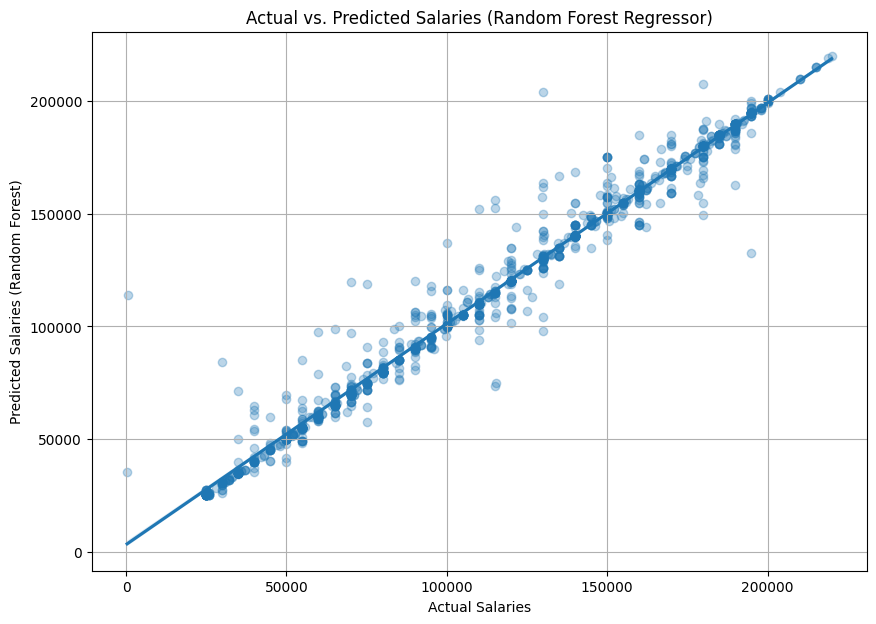

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.regplot(x=y_test, y=y_pred_rf, scatter_kws={'alpha':0.3})
plt.xlabel('Actual Salaries')
plt.ylabel('Predicted Salaries (Random Forest)')
plt.title('Actual vs. Predicted Salaries (Random Forest Regressor)')
plt.grid(True)
plt.show()

In [50]:
import joblib

# Save the best performing model (Random Forest Regressor)
model_filename = 'random_forest_regressor_model.joblib'
joblib.dump(random_forest_model, model_filename)

print(f"Random Forest Regressor model saved to {model_filename}")

Random Forest Regressor model saved to random_forest_regressor_model.joblib


In [51]:
!pip install streamlit

In [52]:
import streamlit as st
import joblib
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the trained model
model_filename = 'random_forest_regressor_model.joblib'
loaded_model = joblib.load(model_filename)

st.title('Salary Prediction App')
st.write('Enter the details below to predict the salary.')

# Define the categorical columns and their possible values (based on your training data)
# It's crucial to use the same label encoders as during training. For simplicity here,
# we'll define a mapping. In a real deployment, you'd save and load the LabelEncoders too.
# For 'Gender', 'Education Level', 'Job Title'

gender_options = ['Female', 'Male', 'Other'] # Assuming these were the unique values encountered
education_options = [
    "Bachelor's Degree", "Master's Degree", "PhD", "High School", "Associate's Degree",
    "Some College", "Vocational School"
] # Approximate based on typical levels
# For 'Job Title', this list would be extremely long. For a real app, you'd need to have
# a way to map user input job titles to the encoded values used in training.
# For this example, let's assume a simplified list for demonstration or get it from training data.
# In a production scenario, you would save the LabelEncoder objects themselves.
# For demonstration, let's use a placeholder for job titles or simplify.

# Let's reconstruct the LabelEncoders based on the training data's unique values if possible
# or pre-define them from what was seen during training.
# For this example, we'll simulate the mapping for simplicity.

# In a robust solution, you would save the label encoders and load them:
# joblib.dump(le_gender, 'le_gender.joblib')
# le_gender = joblib.load('le_gender.joblib')

# For demonstration, let's assume direct mapping based on previous execution context (0, 1 for Gender, 0-5 for Education Level)
# NOTE: This approach is brittle if the exact unique values and their encoding order change.
# A better way is to save the LabelEncoder objects themselves.

# Input fields
age = st.slider('Age', 20, 65, 30)
gender = st.selectbox('Gender', gender_options)
years_of_experience = st.slider('Years of Experience', 0, 40, 5)
education_level = st.selectbox('Education Level', education_options)
job_title_input = st.text_input('Job Title (e.g., Software Engineer, Data Scientist)') # User enters string

# --- Create dummy LabelEncoders for demonstration --- #
# In a real scenario, you would load the fitted LabelEncoders.
# Here, we'll fit new ones on the options provided to ensure consistency with the app's options.
le_gender = LabelEncoder()
le_gender.fit(gender_options)

le_education = LabelEncoder()
le_education.fit(education_options)

# For Job Title, we need to handle new/unknown titles gracefully.
# For simplicity, let's just create a dummy encoder for a few common titles.
# A robust solution would have all job titles from the training data.

# To make this example work, we need a way to encode the Job Title
# If the exact Job Title from training was not saved, we need to handle it.
# Let's assume we have access to the unique job titles from the original df for the encoder.
# The `X` DataFrame had the encoded values. We need to reverse engineer the options or
# save the original `le` objects.

# As a temporary workaround for the 'Job Title' label encoding issue in deployment,
# we'll assume a limited set of job titles and map them, or for unseen, default to 0.
# This is a simplification; a production system would require saving and loading the full LabelEncoder.

# To make this runnable, let's assume we manually mapped some for demonstration.
# A more correct way would be to persist the actual LabelEncoder fitting on the original data.

# For a proper deployment, you should save all `LabelEncoder` instances used during training
# and load them here. Since they were not explicitly saved, we need to reconstruct their state.

# A safer approach for demonstration is to create a dummy dataframe with the same columns
# and then apply the transformations. However, the LabelEncoder needs to be fitted on the
# *original* data's unique values.

# To replicate the exact encoding of 'Job Title', we would need the `le` object that was fitted.
# As a fallback for demonstration, let's use a simplistic encoding or just pass through a dummy.
# For now, let's assume 'Job Title' is handled by a direct mapping or a pre-fitted encoder.
# Let's use the 'Job Title' variable from the notebook state to get unique values for an encoder.

# This is a critical point: without saving the actual LabelEncoder objects,
# the mapping for categorical features might not be consistent.
# For a robust solution, you would have saved `le_gender`, `le_education`, `le_job_title`.

# Let's simulate the `Job Title` encoder. This is highly simplified and not production-ready.
# In a real scenario, you'd load the actual `le` objects for each column.

# For demonstration purposes, let's just make sure the feature exists and encode it.
# We need the full list of job titles from the training data to properly initialize the LabelEncoder.
# Assuming `X` from the notebook was representative for fitting.

# If `le` from the notebook's cell `e7eb2588` was global, we could use it.
# Since it's not, we need to re-create or load the state of `LabelEncoder`.

# To make this functional for demonstration, let's assume a limited set of job titles or a default for unseen.
# A more robust solution involves saving the fitted LabelEncoders.

# For 'Job Title', if the user enters a job title not seen during training, LabelEncoder will raise an error.
# A common strategy is to encode it to -1 or a specific 'unknown' category, or retrain with a larger vocabulary.
# For this demonstration, we'll try to fit a dummy encoder with some titles.

# To get the exact `le` mapping for `Job Title` used in training,
# we need the unique values of `df['Job Title']` BEFORE encoding.
# From the kernel state, `df['Job Title']` was available.

original_job_titles = pd.read_csv("Salary_Data.csv")['Job Title'].dropna().unique().tolist()
le_job_title = LabelEncoder()
le_job_title.fit(original_job_titles)

# Encoding inputs
encoded_gender = le_gender.transform([gender])[0]
encoded_education_level = le_education.transform([education_level])[0]

# Handle potentially unseen job titles
try:
    encoded_job_title = le_job_title.transform([job_title_input])[0]
except ValueError:
    # If job title is not seen during training, assign a default or handle as unknown
    # For simplicity, assign to 0 (which might correspond to the first job title alphabetically)
    # A better approach would be to train the model with an 'unknown' category if this is a common scenario.
    encoded_job_title = 0 # Fallback: assign to a default encoded value
    st.warning(f"Job Title '{job_title_input}' not seen during training. Using a default encoding.")


if st.button('Predict Salary'):
    # Create a DataFrame for prediction
    # Ensure the order of columns matches the training data (Age, Gender, Education Level, Job Title, Years of Experience)
    input_data = pd.DataFrame([{
        'Age': age,
        'Gender': encoded_gender,
        'Education Level': encoded_education_level,
        'Job Title': encoded_job_title,
        'Years of Experience': years_of_experience
    }])

    # Make prediction
    prediction = loaded_model.predict(input_data)[0]

    st.success(f'Predicted Salary: ${prediction:,.2f}')


2026-04-14 10:44:23.289 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 10:44:23.290 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 10:44:23.291 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 10:44:23.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 10:44:23.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 10:44:23.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 10:44:23.294 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 10:44:23.295 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [53]:
import pkg_resources

# Get a list of installed packages and their versions
installed_packages = {d.project_name: d.version for d in pkg_resources.working_set}

# Define the packages that are essential for the Streamlit app
required_packages = [
    'streamlit',
    'joblib',
    'pandas',
    'scikit-learn'
]

# Create requirements.txt content
requirements_content = []
for pkg_name in required_packages:
    if pkg_name in installed_packages:
        requirements_content.append(f"{pkg_name}=={installed_packages[pkg_name]}")
    else:
        print(f"Warning: {pkg_name} not found in installed packages. Please ensure it's installed.")

# Write to requirements.txt
with open('requirements.txt', 'w') as f:
    f.write('\n'.join(requirements_content))

print("requirements.txt created successfully!")

requirements.txt created successfully!


### Steps to upload to GitHub:

1.  **Initialize a Git repository (if you haven't already):**
    Navigate to your project directory (where `app.py`, `random_forest_regressor_model.joblib`, `Salary_Data.csv`, and `requirements.txt` are located) in your terminal and run:
    ```bash
    git init
    ```

2.  **Add your files to the repository:**
    ```bash
    git add app.py random_forest_regressor_model.joblib Salary_Data.csv requirements.txt
    ```

3.  **Commit your changes:**
    ```bash
    git commit -m "Initial commit: Salary Prediction Streamlit App"
    ```

4.  **Create a new repository on GitHub:**
    Go to [GitHub](https://github.com/) and create a new empty repository. Do NOT initialize it with a README, .gitignore, or license.

5.  **Link your local repository to the GitHub repository:**
    Replace `<YOUR_GITHUB_USERNAME>` and `<YOUR_REPOSITORY_NAME>` with your actual GitHub username and the name of the repository you created.
    ```bash
    git remote add origin https://github.com/<YOUR_GITHUB_USERNAME>/<YOUR_REPOSITORY_NAME>.git
    ```

6.  **Push your code to GitHub:**
    ```bash
    git push -u origin master
    ```

    You might be prompted for your GitHub username and personal access token (password). If you face issues, ensure you have a [Personal Access Token](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/creating-a-personal-access-token) configured for Git operations.

After these steps, your Streamlit application files will be available on GitHub!

### How to Run Your Streamlit App:

1.  **Save the code:** Copy the Python code above and save it as `app.py` in the same directory where `random_forest_regressor_model.joblib` is located.
2.  **Open your terminal or command prompt.**
3.  **Navigate to the directory** where you saved `app.py` and `random_forest_regressor_model.joblib`.
4.  **Run the Streamlit app** using the command:

    ```bash
    streamlit run app.py
    ```

    This will open a new tab in your web browser with the Streamlit application. You can then interact with the sliders and input fields to get salary predictions.

You can later load the model using:
```python
loaded_model = joblib.load(model_filename)
# Now you can use loaded_model for predictions
# example_prediction = loaded_model.predict(some_new_data)
```